<a href="https://colab.research.google.com/github/k2herat/Empathetic_AI/blob/base_models_5_classes/face_emotions_zero_shot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install open_clip_torch -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 34.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 14.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

import torch
import torch.nn.functional as F
import open_clip
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [ ]:
model_name = "ViT-L-14"
pretrained = "openai"

model, _, preprocess = open_clip.create_model_and_transforms(
    model_name,
    pretrained=pretrained
)

tokenizer = open_clip.get_tokenizer(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()


open_clip_model.safetensors:   0%|          | 0.00/1.71G [00:00<?, ?B/s]

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-23): 24 x ResidualAttentionBlock(
          (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((1024,), eps=1e-05, elementwi


Количество изображений


,Class Name,Image Count
0,Angry,10148
1,Fear,9732
2,Happy,18439
3,Sad,12553
4,Suprise,8227



Примеры разных классов



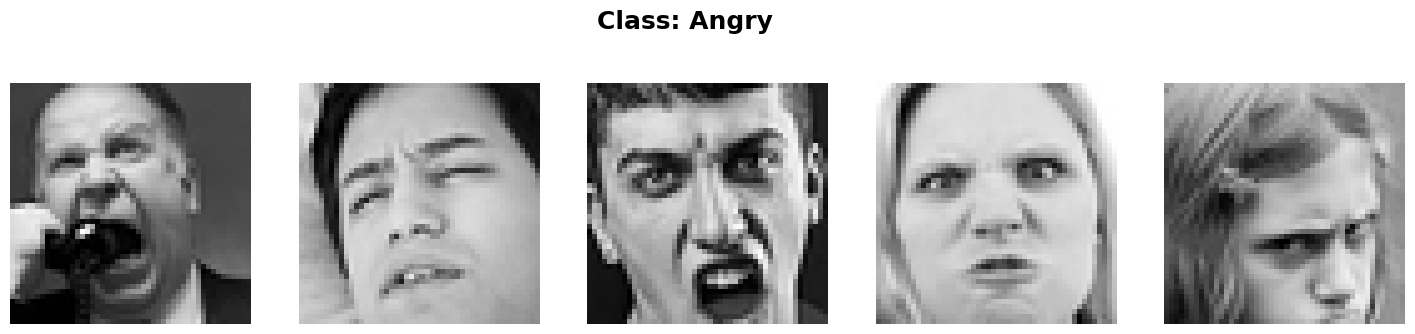

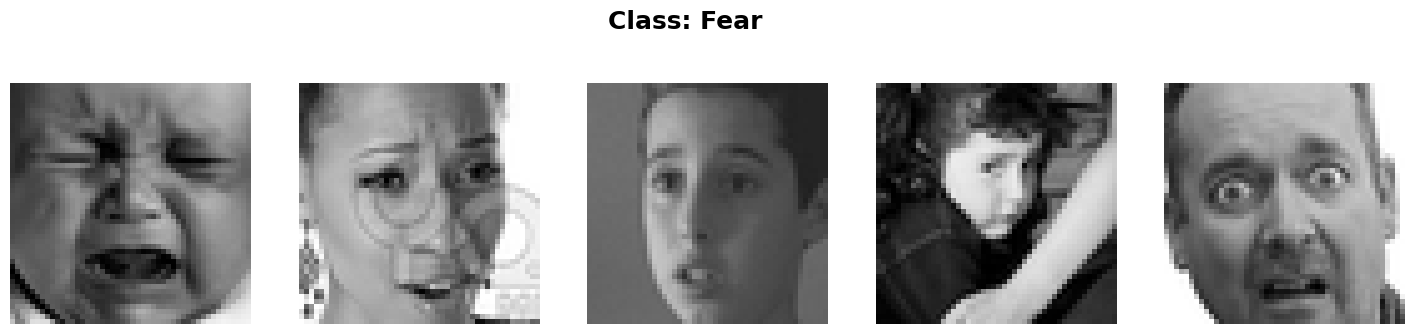

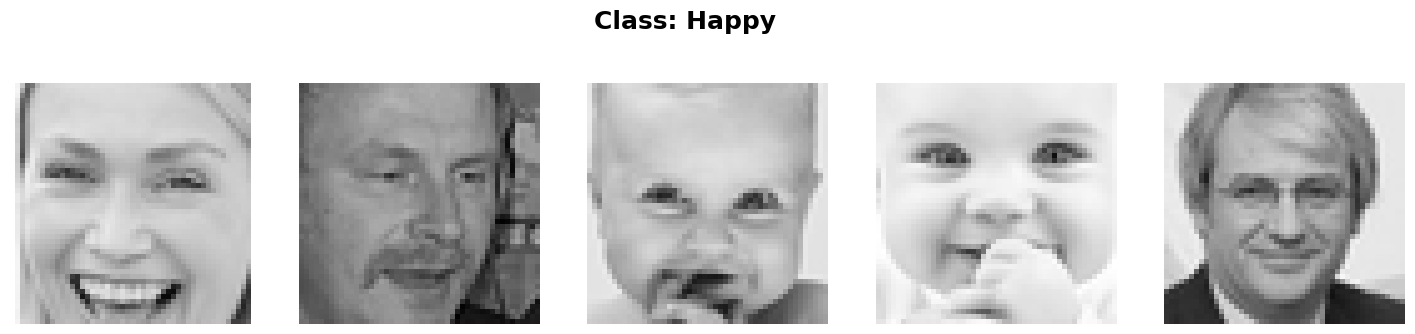

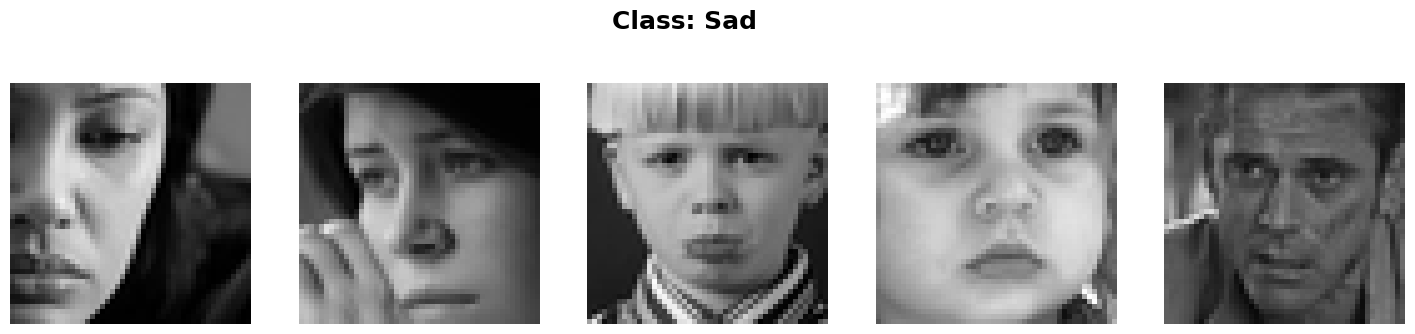

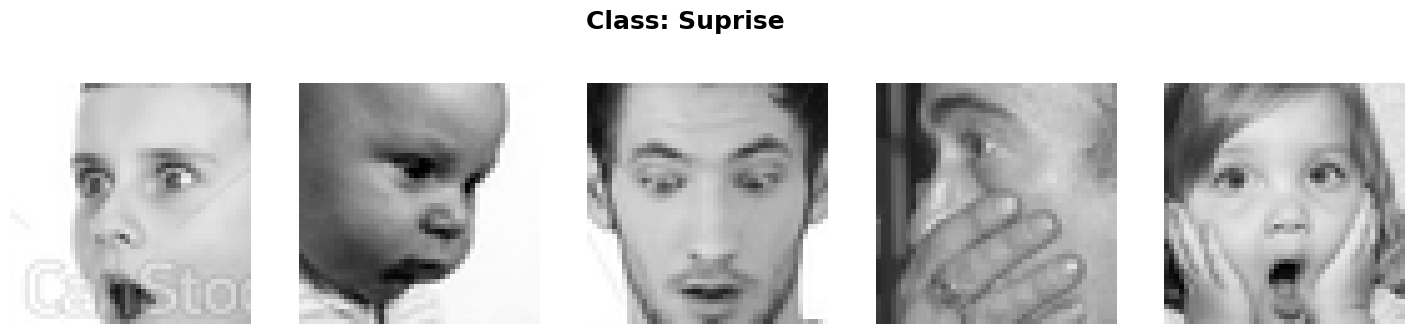

In [ ]:
def visualize_dataset_structure(base_path, n_samples=5):
    class_counts = {}

    for cls in sorted(os.listdir(base_path)):
        folder_path = os.path.join(base_path, cls)
        if os.path.isdir(folder_path):
            imgs = [
                f for f in os.listdir(folder_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]
            class_counts[cls] = len(imgs)

    df_counts = pd.DataFrame({
        "Class Name": class_counts.keys(),
        "Image Count": class_counts.values()
    })

    print("\nКоличество изображений")
    display(
        df_counts.style
        .background_gradient(cmap="Blues")
        .format({"Image Count": "{:.0f}"})
    )

    print("\nПримеры разных классов\n")

    for cls in class_counts.keys():
        folder_path = os.path.join(base_path, cls)
        image_files = [
            os.path.join(folder_path, f)
            for f in os.listdir(folder_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]

        samples = random.sample(image_files, min(n_samples, len(image_files)))

        plt.figure(figsize=(18, 4))
        plt.suptitle(f"Class: {cls}", fontsize=18, fontweight="bold")

        for i, img_path in enumerate(samples, 1):
            img = Image.open(img_path).convert("RGB")
            img = np.array(img)

            plt.subplot(1, n_samples, i)
            plt.imshow(img)
            plt.axis("off")

        plt.show()
visualize_dataset_structure("/kaggle/input/human-face-emotions/Data")


In [ ]:
def extract_image_features(image_path):
    img = Image.open(image_path).convert("RGB")
    image = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feats = model.encode_image(image).cpu().numpy()
    feats = feats / np.linalg.norm(feats)
    return feats.squeeze(0)

def load_dataset(main_folder, n_samples_per_class=None):
    X, y, paths = [], [], []
    emotion_folders = {
        cls: os.path.join(main_folder, cls)
        for cls in os.listdir(main_folder)
        if os.path.isdir(os.path.join(main_folder, cls))
    }

    print("📁 FOUND EMOTION CLASSES:", list(emotion_folders.keys()))

    for emotion, folder in emotion_folders.items():
        image_files = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        if n_samples_per_class:
            image_files = random.sample(image_files, min(n_samples_per_class, len(image_files)))

        for f in tqdm(image_files, desc=f"Processing {emotion}", unit="img"):
            try:
                X.append(extract_image_features(f))
                y.append(emotion)
                paths.append(f)
            except Exception as e:
                print(f"Error processing {f}: {e}")

    return np.array(X), np.array(y), np.array(paths)

main_folder = "/kaggle/input/human-face-emotions/Data"
X, y, paths = load_dataset(main_folder, n_samples_per_class=1500)

print("\nEmbeddings shape:", X.shape)
print("Labels shape:", y.shape)

X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X, y, paths, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", len(X_train), "Test size:", len(X_test))

unique, counts = np.unique(y, return_counts=True)
print("Class counts:", dict(zip(unique, counts)))


📁 FOUND EMOTION CLASSES: ['Fear', 'Suprise', 'Angry', 'Sad', 'Happy']


Processing Happy: 100%|██████████| 1500/1500 [01:09<00:00, 21.59img/s]


Embeddings shape: (7500, 768)
Labels shape: (7500,)
Train size: 6000 Test size: 1500
Class counts: {'Angry': 1500, 'Fear': 1500, 'Happy': 1500, 'Sad': 1500, 'Suprise': 1500}


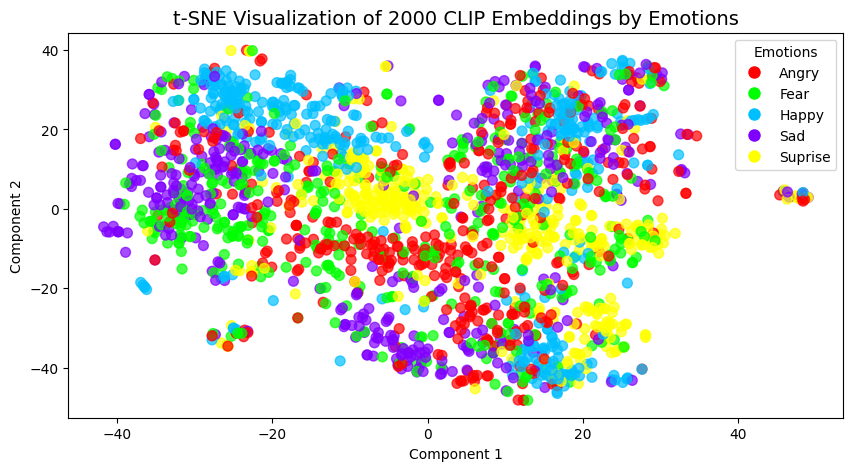

In [ ]:
num_samples = min(2000, len(X))
indices = random.sample(range(len(X)), num_samples)
X_sample = X[indices]
y_sample = np.array(y)[indices]
paths_sample = np.array(paths)[indices]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_sample)

unique_breeds = sorted(np.unique(y_sample))

color_palette = [
    "#FF0000",
    "#00FF00",
    "#00BFFF",
    "#8000FF",
    "#FFFF00",
]

color_map = {breed: color_palette[i % len(color_palette)] for i, breed in enumerate(unique_breeds)}
colors = [color_map[label] for label in y_sample]

plt.figure(figsize=(10, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, alpha=0.7, s=50)

plt.title(f"t-SNE Visualization of {num_samples} CLIP Embeddings by Emotions", fontsize=14)
plt.xlabel("Component 1")
plt.ylabel("Component 2")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=breed,
           markerfacecolor=color_map[breed], markersize=10)
    for breed in unique_breeds
]
plt.legend(handles=legend_elements, title="Emotions", loc='best')

plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

label_map = {
    "Angry": 0,
    "Fear": 1,
    "Happy": 2,
    "Sad": 3,
    "Suprise": 4
}

inv_label_map = {v: k for k, v in label_map.items()}

y_train_num = np.array([label_map[label] for label in y_train])
y_test_num  = np.array([label_map[label] for label in y_test])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

clf_svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
clf_svm.fit(X_train_scaled, y_train_num)

def evaluate_model(model, X_test, y_test_num, model_name="Model"):
    y_pred_num = model.predict(X_test)
    y_pred_labels = [inv_label_map[p] for p in y_pred_num]
    y_true_labels = [inv_label_map[p] for p in y_test_num]

    acc = accuracy_score(y_true_labels, y_pred_labels)
    print(f"\n{model_name} Accuracy: {acc*100:.2f}%")
    print(f"{model_name} Classification Report:\n",
          classification_report(y_true_labels, y_pred_labels))

    return y_pred_labels

y_pred_svm = evaluate_model(clf_svm, X_test_scaled, y_test_num, model_name="SVM Emotion Classifier")



SVM Emotion Classifier Accuracy: 74.93%
SVM Emotion Classifier Classification Report:
               precision    recall  f1-score   support

       Angry       0.70      0.70      0.70       300
        Fear       0.65      0.57      0.61       300
       Happy       0.92      0.93      0.93       300
         Sad       0.63      0.70      0.67       300
     Suprise       0.84      0.85      0.84       300

    accuracy                           0.75      1500
   macro avg       0.75      0.75      0.75      1500
weighted avg       0.75      0.75      0.75      1500



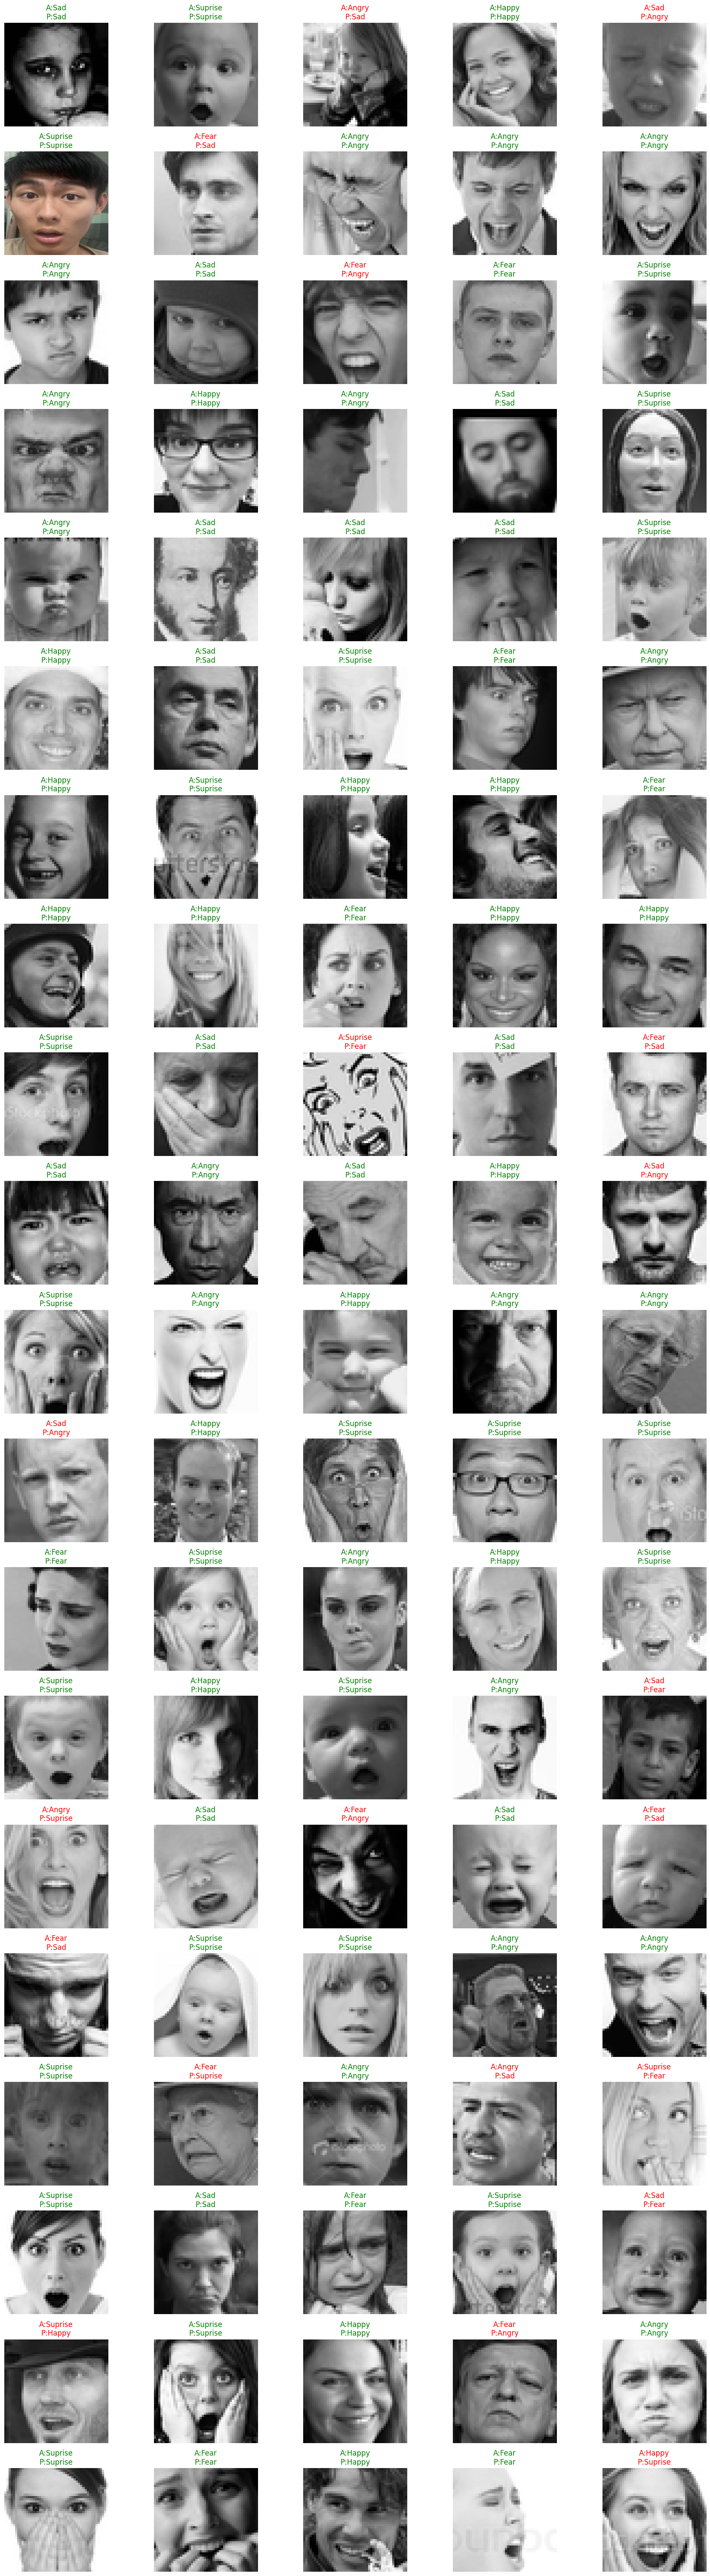

In [ ]:

def show_random_predictions_with_images(X, y, clf, image_paths, n=100):
    idxs = np.arange(len(y))
    chosen = np.random.choice(idxs, size=min(n, len(y)), replace=False)
    n_cols = 5
    n_rows = int(np.ceil(len(chosen) / n_cols))
    plt.figure(figsize=(18, n_rows * 3))

    for i, idx in enumerate(chosen, 1):
        img = Image.open(image_paths[idx]).convert("RGB")
        feats_scaled = scaler.transform(X[idx].reshape(1, -1))
        pred_num = clf.predict(feats_scaled)[0]
        pred_label = inv_label_map[pred_num]
        actual_label = y[idx]

        plt.subplot(n_rows, n_cols, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"A:{actual_label}\nP:{pred_label}",
                  color="green" if pred_label == actual_label else "red")

    plt.tight_layout()
    plt.show()

y_pred_svm = clf_svm.predict(X_test_scaled)
show_random_predictions_with_images(X_test, y_test, clf_svm, paths_test, n=100)


Angry: 52/100 = 52.00%
Fear: 48/100 = 48.00%
Happy: 74/100 = 74.00%
Sad: 59/100 = 59.00%
Suprise: 84/100 = 84.00%

Overall: 317/500 = 63.40%


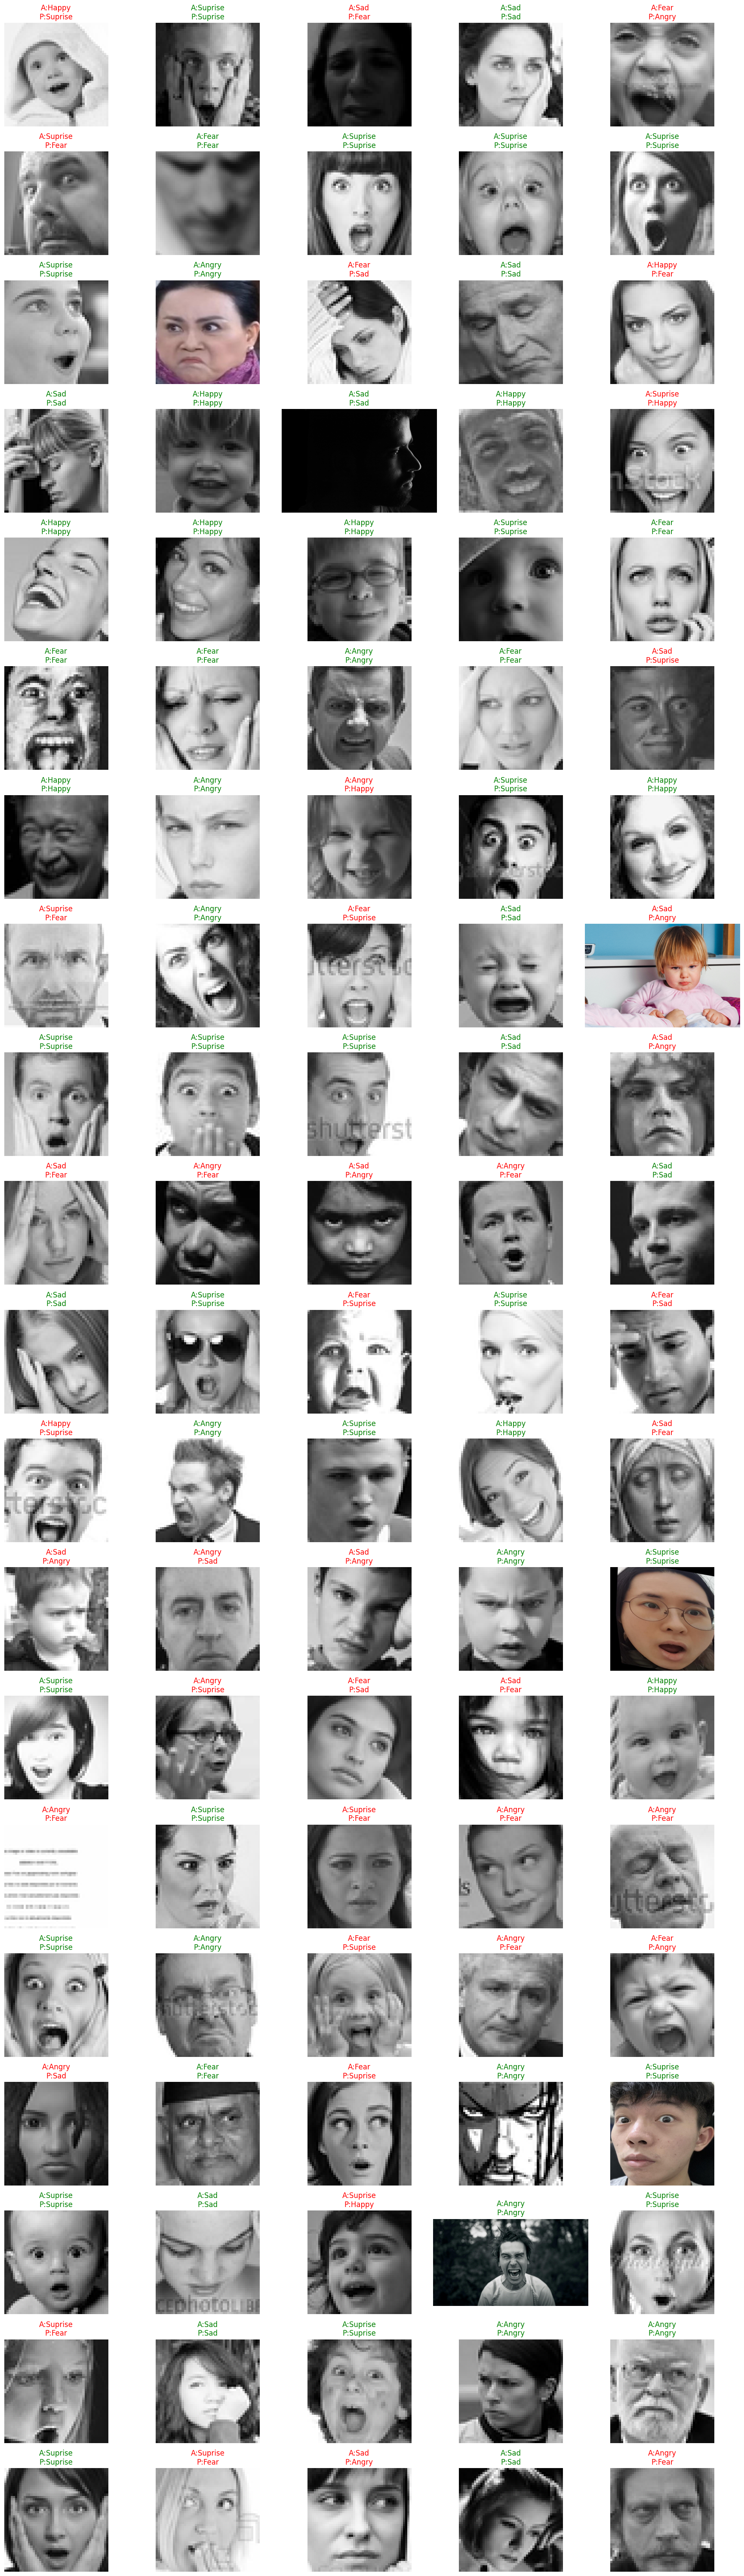

In [ ]:

emotion_prompts = {
    "Angry":   "a person with an angry face",
    "Fear":    "a person with a fearful face",
    "Happy":   "a person with a happy face",
    "Sad":     "a person with a sad face",
    "Suprise": "a person with a surprised face"
}

def build_emotion_vectors(method="norm_then_avg"):
    emotion_info = {}
    with torch.no_grad():
        for emotion, prompt in emotion_prompts.items():
            tokens = tokenizer(prompt).to(device)
            text_feats = model.encode_text(tokens).float()
            if method == "norm_then_avg":
                per_prompt = text_feats / text_feats.norm(dim=-1, keepdim=True)
                emotion_vec = per_prompt.mean(dim=0)
                emotion_vec = emotion_vec / emotion_vec.norm()
            else:
                emotion_vec = text_feats.mean(dim=0)
                emotion_vec = emotion_vec / emotion_vec.norm()
            emotion_info[emotion] = {"vec": emotion_vec}

    all_text = torch.stack([v["vec"] for v in emotion_info.values()], dim=0)
    all_text = all_text / all_text.norm(dim=-1, keepdim=True)
    return emotion_info, all_text

def predict_image(image_path, emotion_info, all_text, temperature=100.0):
    img = Image.open(image_path).convert("RGB")
    image = preprocess(img).unsqueeze(0).to(device)
    with torch.no_grad():
        image_feat = model.encode_image(image).float()
        image_feat = image_feat / image_feat.norm(dim=-1, keepdim=True)
    cos_sim = (image_feat @ all_text.T).squeeze(0)
    emotions = list(emotion_prompts.keys())
    return emotions[cos_sim.argmax().item()]

def visualize_predictions(image_paths, true_labels, pred_labels, n=100):
    idxs = np.arange(len(true_labels))
    chosen = np.random.choice(idxs, size=min(n, len(true_labels)), replace=False)
    n_cols = 5
    n_rows = int(np.ceil(len(chosen) / n_cols))
    plt.figure(figsize=(18, n_rows * 3))

    for i, idx in enumerate(chosen, 1):
        img = Image.open(image_paths[idx]).convert("RGB")
        actual = true_labels[idx]
        pred = pred_labels[idx]

        plt.subplot(n_rows, n_cols, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"A:{actual}\nP:{pred}",
                  color="green" if actual == pred else "red")

    plt.tight_layout()
    plt.show()

def predict_from_main_folder(main_folder, n_samples_per_emotion=20, visualize=True):
    emotion_folders = {
        emotion: os.path.join(main_folder, emotion)
        for emotion in emotion_prompts.keys()
    }

    emotion_info, all_text = build_emotion_vectors()

    all_true = []
    all_pred = []
    all_paths = []

    overall_correct = 0
    overall_total = 0

    for emotion, folder_path in emotion_folders.items():
        image_files = [
            os.path.join(folder_path, f)
            for f in os.listdir(folder_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]

        if len(image_files) == 0:
            continue

        sample_images = random.sample(image_files, min(n_samples_per_emotion, len(image_files)))
        correct = 0

        for img_path in sample_images:
            pred = predict_image(img_path, emotion_info, all_text)
            if pred == emotion:
                correct += 1

            all_true.append(emotion)
            all_pred.append(pred)
            all_paths.append(img_path)

        acc = correct / len(sample_images)
        print(f"{emotion}: {correct}/{len(sample_images)} = {acc*100:.2f}%")

        overall_correct += correct
        overall_total += len(sample_images)

    print(f"\nOverall: {overall_correct}/{overall_total} = {(overall_correct/overall_total)*100:.2f}%")

    if visualize:
        visualize_predictions(all_paths, all_true, all_pred, n=100)


main_folder = "/kaggle/input/human-face-emotions/Data"
predict_from_main_folder(main_folder, n_samples_per_emotion=100, visualize=True)
